A file to actually build the pipes (rather than analyse the data)

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats

from sklearn.model_selection import train_test_split, cross_val_predict, cross_validate, RandomizedSearchCV

# classifier so lets try logistic regression as simplest, then  random forest, XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report#, roc_curve, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PolynomialFeatures, SplineTransformer
# from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier
import pickle
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import zscore

In [2]:
# loading the data
df = pd.read_csv('data/Credit_Risk_Benchmark_Dataset.csv')

#TODO: could try and purposefully make an imbalanced dataset

In [3]:
# mask out data for revolving utilisation greater than 5 (threshold determined as suitable from EDA)

print('initial shape: \n', df.shape)
df_filtered = df[df['rev_util'] < 5]

# filter out bad values for late 90 etc.
df_filtered = df_filtered[(df['late_90'] != 98) & (df['late_90'] != 96)]

# filter out bad values for monthly income (where equal to 1 or zero - very likely an error)
mask_inc_bad_data = (df_filtered['monthly_inc'] == 1) | ((df_filtered['monthly_inc'] == 0) & (df_filtered['debt_ratio'] != 0))
df_filtered = df_filtered[~mask_inc_bad_data]


# create mask where extreme debt ratio coincide with unlikely monthly income
mask_debt_ratio_bad_data = ((zscore(df_filtered['debt_ratio']) > 5) & (df_filtered['monthly_inc'] < 500))
# filter data using mask
df_filtered = df_filtered[~mask_debt_ratio_bad_data]

print('shape after filtering: \n', df_filtered.shape)


# # TEST: manually filter to people with no late payments
# df_filtered = df_filtered[(df_filtered['late_30_59'] == 0) & (df_filtered['late_60_89'] == 0) & (df_filtered['late_90'] == 0)]

# seperate out features from target
X = df_filtered.drop(columns=['dlq_2yrs'])
y = df_filtered['dlq_2yrs']

print(df_filtered['dlq_2yrs'].value_counts())
# here do an initial train, test split. The testing data here will be a final hold out testing data used for the 
# final model
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=0.8)





initial shape: 
 (16714, 11)
shape after filtering: 
 (16353, 11)
dlq_2yrs
1    8177
0    8176
Name: count, dtype: int64


C:\Users\Flynn\AppData\Local\Temp\ipykernel_18916\1190413708.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = df_filtered[(df['late_90'] != 98) & (df['late_90'] != 96)]


Create custom transformer to remove if variational influence factor exceeds trheshold

In [ ]:
class SelectByVIF(BaseEstimator, TransformerMixin):
    """ Selects features with VIF below a certain threshold to remove features that are 
        colinear """
    
    def __init__(self, vif_threshold=5):
        # intialise threshold for VIF
        self.vif_threshold = vif_threshold


    def fit(self, X, y=None):

        # y=None is for consitency with the sklearn API
        #TODO: could use validate data function or something and if dataframe
        # get X.values otherwise leave in array format (although maybe not worry for now
        # as not going to use in final model)


        # compute VIF scores for each feature (fits to each feature using all other features)
        # to compute coefficient of determination
        # note that sklearn convention is underscore suffix for things learned during fit
        vif_scores_ = np.array([variance_inflation_factor(X.values, i) for i in range(len(X.columns))])

        # create mask for ones giving true where VIF is underneath threshold
        self.mask_ = vif_scores_ < self.vif_threshold

        # returning self allows for method chaining
        return self

    def transform(self, X):
        # use mask to remove features where vif exceeds threshold (a boolean can be used to remove
        # redundant columns)
        X = X.iloc[:, self.mask]

        return X

Index(['rev_util', 'late_30_59', 'debt_ratio', 'monthly_inc', 'late_90',
       'real_estate', 'late_60_89', 'dependents'],
      dtype='str')

In [53]:
# create custom log transformer
# np.log1p returns natural logarithm of input array +1 (so prevents negative values)
LogTransformer = FunctionTransformer(np.log1p)

# create custom function for natural logarithm plus two
def logp2(X):
    
    return np.log(X + 2)


# create custom function to put in function transformer
def return_deg_stacked(X):
    """ Use column stack to stack as columns (because h stack, although column wise,
      will stack to same column, need columnstack to create seperate column) """

    return np.column_stack((X, X**2))


# Creating custom transformer that returns squared polynomial feature
DegreeTransformer = FunctionTransformer(return_deg_stacked)

# create custom transformer for logp2
LogTransformer2 = FunctionTransformer(logp2)


# create column transformer for creating polynomial features
# insert a list of tuples with name of step, tranformer to apply, and column to apply to
# need to set remainder='passthrough' or else all column sthat not applied transformer to will be removed!
ct_poly_debt = ColumnTransformer([('polynomial creation', DegreeTransformer, ['open_credit', 'monthly_inc', 'debt_ratio', 'late_30_59', 'late_60_89', 'late_90'])], remainder='passthrough')
# note that checking interaction of late payment with other predictors of default
ct_debt_income_interact = ColumnTransformer([('interaction', PolynomialFeatures(degree=2, interaction_only=True, include_bias=True), 
                                             ['late_30_59', 'rev_util'])], remainder='passthrough')

# create custom transformer with log scaling for income, 
# debt ratio and revolving utilisation, standardisation for all others
# ct_mix_scale = ColumnTransformer([('scale_log', LogTransformer, ['monthly_inc', 'rev_util', 'debt_ratio', 'late_30_59', 'late_60_89','late_90']),
#                                   ('scale_standard', StandardScaler(), ['real_estate',
#                                                                        'dependents', 'age', 'open_credit'])], remainder='passthrough')

# as will standardise all terms afterwards (also after log scaling), pass all through
# test spline transform for open credit
ct_mix_scale = ColumnTransformer([('scale_log', LogTransformer, ['monthly_inc', 'rev_util', 'debt_ratio']), # 'late_30_59', 'late_60_89','late_90'
                                  ('spline', SplineTransformer(n_knots=3, degree=3), ['open_credit'])], remainder='passthrough')



###################
# define estimators

# key is name for step, value is am estimator object
estimators_lr_log_scale = [('scale', LogTransformer), ('clf', LogisticRegression(max_iter=10000, solver='saga'))]
# estimators_lr_mix_scale = [('scale', ct_mix_scale), ('clf', LogisticRegression(max_iter=10000, solver='saga'))]

# standardise all variables after some are log transformed. This is to ensure regularisation does not unequally penalise variables
estimators_lr_mix_scale = [('log scale', ct_mix_scale), ('stand scale', StandardScaler()), ('clf', LogisticRegression(max_iter=10000, solver='saga'))]

# testing polynomial features
# thinking that best to log scale first before polynomial features
# estimators_lr_poly_features = [('scale', LogTransformer), ('polynomial_features', ct_poly_debt), ('clf', LogisticRegression(max_iter=10000, solver='saga', l1_ratio=0.5))]

# # as not squaring the features, try polynomial before scaling (as interactions between log features may be weird?)
# estimators_lr_interact_only_poly = [('polynomial_features', ct_debt_income_interact), ('scale', LogTransformer), ('clf', LogisticRegression(max_iter=10000, solver='saga', l1_ratio=1.0, C=1))]


# # and tree algorithms
estimators_rf = [('clf', RandomForestClassifier())]
estimators_xgb = [('clf', XGBClassifier())]


# put estimators into pipes (which require transformers, with calssifier or regressor at the end)
# pipe_lr_stand_scale = Pipeline(estimators_lr_stand_scale)
pipe_lr_log_scale = Pipeline(estimators_lr_log_scale)
pipe_lr_mix_scale = Pipeline(estimators_lr_mix_scale)
# pipe_lr_poly_features = Pipeline(estimators_lr_poly_features)
# pipe_lr_interact_only_poly = Pipeline(estimators_lr_interact_only_poly)
pipe_rf = Pipeline(estimators_rf)
pipe_xgb = Pipeline(estimators_xgb)


print(pipe_xgb[-1].get_params())


{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [54]:
# now perform cross validation on the pipelineloget out
# define scoring metrics (as a list) - both roc-auc and pr-auc to eveluate tradeoffs (although note 
# latter used more when imbalanced dataset - not the case here)
scoring = ['roc_auc', 'average_precision', 'recall']


# put pipes in dictionary
pipe_dictionary = {               
                   'lr_log_scale': {'pipe': pipe_lr_log_scale},
                   'lr_mix_scale': {'pipe': pipe_lr_mix_scale},
                #    'lr_poly_features': {'pipe': pipe_lr_poly_features},
                #    'lr_interact_only_poly': {'pipe': pipe_lr_interact_only_poly},
                #    'rf': {'pipe': pipe_rf},
                   'xgb': {'pipe': pipe_xgb},
                   }


# loop through pipes
for m, model in pipe_dictionary.items():
    print(m)
    # perform cross validation to get score for each pipe
    # note that X_train here is just ioslating from 'final' test version of data
    #scores = cross_val_score(model['pipe'], X_train, y_train, cv=5, scoring='roc_auc')
    scores = cross_validate(model['pipe'], X_train, y_train, cv=5, scoring=scoring)

    # then save mean and std of scores
    for i, score in enumerate(scoring):
        # when using corss validate, scores are now dictionary
        # so need to extract appropriate score which cross_validate prefixes with 'test'
        # then save to dictionary

        model[f'{score}' + '_mean'] = scores['test_' + score].mean()
        
        model[f'{score}' + '_std'] = scores['test_' + score].std()

    print(scores['test_recall'].mean())
    # model['auc_mean'] = scores.mean()
    # model['auc_std'] = scores.std()

# creating up to degree three terms for all features massively increases cross validation time for 
# logistic regression - because rather than 11 features, have all possible permutations of combinations of
# these - so ridiculously large number of features!

lr_log_scale
0.722995546637095
lr_mix_scale
0.7350960201369453
xgb
0.746589803617844


In [29]:
# loop through pipes - using cross_val_predict, to get outputted predictions for classes
for m, model in pipe_dictionary.items():
    print(m)
    # get predictions
    model[f'y_pred'] = cross_val_predict(model['pipe'], X_train, y_train, cv=5)

lr_log_scale
lr_mix_scale
rf
xgb


In [64]:
# fit pipe on full training set to check coefficients


# get the coefficients from the pipe
for m, model in pipe_dictionary.items():
    print(m)

    if 'lr' in m:

        # fit the model
        model['pipe'].fit(X_train, y_train)

        # get coefficients for fit if logistic regression
        coeffs = model['pipe'].named_steps['clf'].coef_
        print(coeffs)
        # get feature names if logistic regression

        if 'log_scale' not in m:
            pass
            # features = model['pipe'].named_steps['polynomial_features'].get_feature_names_out()
        else:
            features = X_train.columns

        if 'mix_scale' in m:
            knot_coeffs = model['pipe'].named_steps['log scale'].named_transformers_['spline'].bsplines_
            print(knot_coeffs)
        # model['df_coeffs'] = pd.DataFrame({'feature': features,
        #                                    'coeffs': coeffs.flatten()})
        
# print(pipe_dictionary['lr_log_scale']['df_coeffs'].head(50), 'n')
# # print(pipe_dictionary['lr_interact_only_poly']['df_coeffs'].head(50))
# print(pipe_dictionary['lr_mix_scale']['df_coeffs'].head(50))

lr_log_scale
[[ 2.73856193 -0.77089531  1.19374826  0.67618706 -0.13729225  0.24543996
   1.83193321  0.02511255  1.61093261  0.13476832]]
lr_mix_scale
[[-0.15720578  0.76122106  0.10917245  0.30059209 -0.3583142   0.25909019
  -0.18151509  0.11256667 -0.24341385  0.7007215   0.94461705  0.11588571
   0.61862872  0.06738502]]
xgb


C:\Users\Flynn\AppData\Local\Temp\ipykernel_14588\3118216271.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


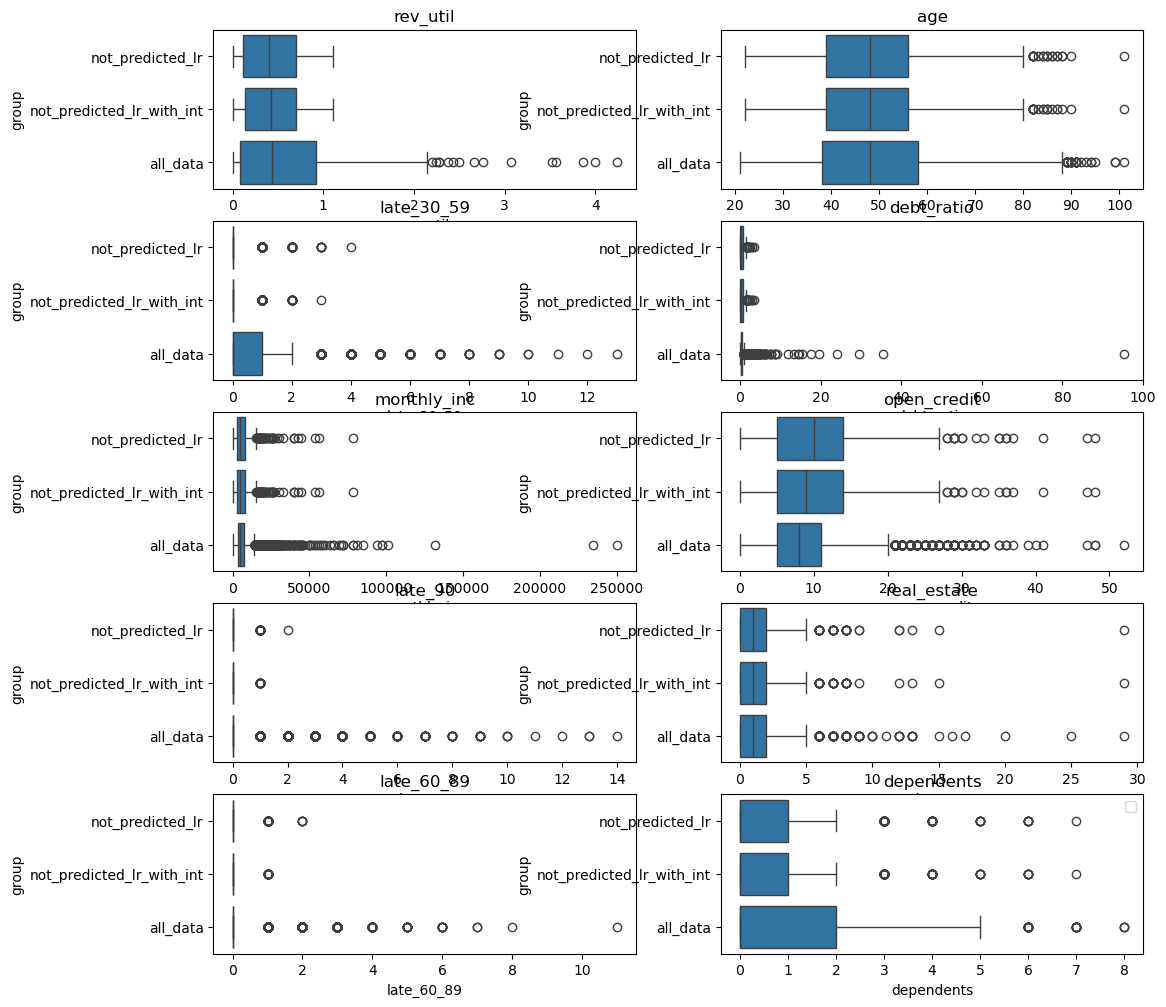

In [41]:
# concatentate with features so that can determine

df_rf_preds = pd.DataFrame(data=pipe_dictionary['rf']['y_pred'], columns=['y_pred'])
df_xgb_preds = pd.DataFrame(data=pipe_dictionary['xgb']['y_pred'], columns=['y_pred'])
df_lr_preds = pd.DataFrame(data=pipe_dictionary['lr_log_scale']['y_pred'], columns=['y_pred'])
df_lr_preds_with_int = pd.DataFrame(data=pipe_dictionary['lr_interact_only_poly']['y_pred'], columns=['y_pred'])

# get index where rf predicts default where lr does not
# not_predicted_index = df_rf_preds[df_rf_preds['y_pred'] == 1].index.difference(df_lr_preds[df_lr_preds['y_pred'] == 1].index)
# not_predicted_index = df_rf_preds[df_rf_preds['y_pred'] == 1].index.difference(df_xgb_preds[df_xgb_preds['y_pred'] == 1].index)

not_predicted_index = df_xgb_preds[df_xgb_preds['y_pred'] == 1].index.difference(df_lr_preds[df_lr_preds['y_pred'] == 1].index)
not_predicted_with_int_index = df_xgb_preds[df_xgb_preds['y_pred'] == 1].index.difference(df_lr_preds_with_int[df_lr_preds_with_int['y_pred'] == 1].index)




# now get feature data at indexes where predicted differently
lr_conservative_data = X_train.iloc[not_predicted_index, :]
lr_with_int_conservative_data = X_train.iloc[not_predicted_with_int_index, :]

# assign a variable called group
lr_conservative_data['group'] = 'not_predicted_lr'
lr_with_int_conservative_data['group'] = 'not_predicted_lr_with_int'

# create copy of training data
X_train = X_train.copy()
X_train['group'] = 'all_data'

# then concatentate. By doing so, can now plot box plots across the group for each variable
combined = pd.concat((lr_conservative_data, lr_with_int_conservative_data, X_train))

# could plot box plots to compare distributions for each variable

fig, axs = plt.subplots(5, 2, figsize=(12, 12))

for i, ax in enumerate(axs.flatten()):

    # plot the distribution for data that not predicted to default by logistic regression
    sns.boxplot(data=combined, x=combined[str(X_train.columns[i])], y='group', ax=ax)
    ax.set_title(str(X_train.columns[i]))

plt.legend()
plt.show()




In [75]:
for m, model in pipe_dictionary.items():
    print(m)
    for score in scoring:

        print(f'\n {score} mean: ', model[f'{score}_mean'], f'\n {score} std: ', model[f'{score}_std'])


lr_log_scale

 roc_auc mean:  0.8475788586277865 
 roc_auc std:  0.004592021079074215

 average_precision mean:  0.8486543545184064 
 average_precision std:  0.0034049854314025106

 recall mean:  0.722995546637095 
 recall std:  0.014233168465735788
lr_poly_features

 roc_auc mean:  0.8503683576389716 
 roc_auc std:  0.005171038530472892

 average_precision mean:  0.8506618432623168 
 average_precision std:  0.0031328118294967244

 recall mean:  0.732186372357466 
 recall std:  0.01339160412819492
rf

 roc_auc mean:  0.8428776158476022 
 roc_auc std:  0.0028342003510463186

 average_precision mean:  0.8349544257920541 
 average_precision std:  0.004699922938259614

 recall mean:  0.7577748440736242 
 recall std:  0.004068855755377205
xgb

 roc_auc mean:  0.8413052300855833 
 roc_auc std:  0.0026036206390626254

 average_precision mean:  0.8398177928408759 
 average_precision std:  0.0018443086426555458

 recall mean:  0.746589803617844 
 recall std:  0.010143574786199394


In [ ]:
# check a hyper parameter grid search - use random search

# currently the random forest and XGboost have best recall, while logistic regression the best precision
# lets see if can squeeze out more performance from the tree based algorithms

# create dictionary of hyperparameters
# use normal distribution for number of estimators
# can't use statistaical distribution where need whole number output

# param_distributions_rf = {'n_estimators': [100, 200, 500, 1000],
#                           'max_depth': [10, 30, 50, 70], 
#                           'min_samples_split': [2, 5, 8, 11]}


# NOTE: use combination of scoring metrics (e.g., average precision). Accuracy generally too 
# generic a scoring metric (will probably use recall as a metric to prioritise getting positive cases)

#NOTE: need to prefix parameters with step name when using pipeline so sklearn knows where to look for
# the classifier (with double underscore following)

# converting data type to integer as max depth etc cannot be a float
param_distributions_rf = {'clf__n_estimators': np.linspace(100, 2000, 20, dtype=np.int64),
                          'clf__max_depth': np.linspace(2, 20, 10, dtype=np.int64), 
                          'clf__min_samples_split': np.linspace(2, 20, 10, dtype=np.int64),
                          'clf__min_samples_leaf': np.linspace(1, 10, 10, dtype=np.int64),
                          'clf__criterion': ['gini', 'entropy'],
                          'clf__bootstrap': [True, False],                        
                          }

# NOTE: using log uniform distribution for parameters that scale by orders of magnitude
param_distributions_xgb = {'clf__learning_rate': stats.loguniform(0.01, 1), 
                          'clf__n_estimators': np.linspace(100, 2000, 20, dtype=np.int64),
                          'clf__max_depth': np.linspace(2, 20, 10, dtype=np.int64), 
                          'clf__gamma': np.linspace(0, 5, 6, dtype=np.float64),
                          'clf__subsample': np.linspace(0.1, 1, 10, dtype=np.float64),
                          'clf__colsample_bytree': np.linspace(0.1, 1, 10, dtype=np.float64),
                          'clf__reg_alpha': np.linspace(0, 1, 11, dtype=np.int64),
                          'clf__reg_lambda': np.linspace(0, 1, 11, dtype=np.int64),       
                          }

param_distributions_lr = {'clf__C': stats.loguniform(1e-2, 1e2),
                           'clf__l1_ratio': stats.uniform(),
                          }

# Define the randomised search objects, using three pipes: logistic regression with standardisation, 
# random forest and XGboost.

# here we score baed upon recall, because the cost of not catching someone who might default will be large
clf_rf = RandomizedSearchCV(pipe_rf, param_distributions_rf, cv=5, scoring='recall', n_iter=20)
clf_xgb = RandomizedSearchCV(pipe_xgb, param_distributions_xgb, cv=5, scoring='recall', n_iter=20)
clf_lr_logScaled = RandomizedSearchCV(pipe_lr_log_scale, param_distributions_lr, cv=5, scoring='recall', n_iter=20)

# fitting models to the training data
search_xgb = clf_xgb.fit(X_train, y_train)
search_rf = clf_rf.fit(X_train, y_train)
search_lr = clf_lr_logScaled.fit(X_train, y_train)


TypeError: file must have a 'write' attribute

In [ ]:
# for final inference, get final scoring metrics, as well as time taken for the inference
# save fitted models to pickle
pickle.dump(search_xgb, open('saved_models/clf_xgb.pkl', 'wb'))
pickle.dump(search_rf, open('saved_models/clf_rf.pkl', 'wb'))
pickle.dump(search_lr, open('saved_models/clf_lr.pkl', 'wb'))

In [35]:
#TODO: when doing inference for logistic regression, remeber to scale the data!
search_xgb.best_score_

np.float64(0.7552244623579987)

In [36]:
# now test models on the testing (validation) data
y_pred_xgb = search_xgb.predict(X_test)
y_pred_rf = search_rf.predict(X_test)
y_pred_lr = search_lr.predict(X_test)

In [38]:
# now produce classification report

print('\n for xgb: \n', classification_report(y_true=y_test, y_pred=y_pred_xgb))
print('\n for rf: \n', classification_report(y_true=y_test, y_pred=y_pred_rf))
print('\n for lr: \n', classification_report(y_true=y_test, y_pred=y_pred_lr))


 for xgb: 
               precision    recall  f1-score   support

           0       0.78      0.79      0.78      1703
           1       0.78      0.76      0.77      1622

    accuracy                           0.78      3325
   macro avg       0.78      0.78      0.78      3325
weighted avg       0.78      0.78      0.78      3325


 for rf: 
               precision    recall  f1-score   support

           0       0.78      0.76      0.77      1703
           1       0.76      0.77      0.76      1622

    accuracy                           0.77      3325
   macro avg       0.77      0.77      0.77      3325
weighted avg       0.77      0.77      0.77      3325


 for lr: 
               precision    recall  f1-score   support

           0       0.74      0.82      0.78      1703
           1       0.79      0.69      0.74      1622

    accuracy                           0.76      3325
   macro avg       0.76      0.76      0.76      3325
weighted avg       0.76      0.76    

In [ ]:
# plot confusion matrices for models
